In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import os

base = "/kaggle/input"

for root, dirs, files in os.walk(base):
    if "crack-seg" in root.lower():
        level = root.replace(base, "").count(os.sep)
        indent = "  " * level
        print(f"{indent}{root}")
        subindent = "  " * (level + 1)
        for f in files[:5]:
            print(f"{subindent}{f}")

      /kaggle/input/datasets/akashbhavanisankar/crack-seg-ultralytics
        crack-seg.yaml
        /kaggle/input/datasets/akashbhavanisankar/crack-seg-ultralytics/labels
          /kaggle/input/datasets/akashbhavanisankar/crack-seg-ultralytics/labels/val
            2563.rf.a9645955318dae0a1ff7f249a262a59b.txt
            3053.rf.cdeebbcb620b3598d8ec1d008f386711.txt
            3230.rf.cdf99c85e1872477118a3b6537bbdff8.txt
            3584.rf.65d9829c42a36a0b1aacfc88300222ac.txt
            2079.rf.371fd1cc8384c68696af4b364662f029.txt
          /kaggle/input/datasets/akashbhavanisankar/crack-seg-ultralytics/labels/test
            2323.rf.06768caef93b3a44d3c59325a03230eb.txt
            2388.rf.dd8dc351bb67d6bfc9ae331dae59cb0d.txt
            1686.rf.809fb1b51c607e5cf787e44ef4ddd7b8.txt
            3266.rf.e869e737911fd5b9235a9dcb6e297cc3.txt
            3262.rf.c9dc3251366364177a515678a4b7deca.txt
          /kaggle/input/datasets/akashbhavanisankar/crack-seg-ultralytics/labels/train


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 31.2 MB/s eta 0:00:0000:01
DATA_ROOT: /kaggle/input/datasets/akashbhavanisankar/crack-seg-ultralytics
Train images: 3717
Val images: 200
Test images: 112


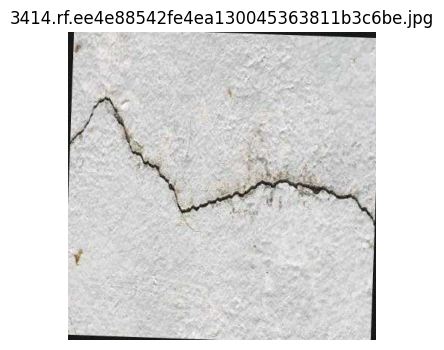

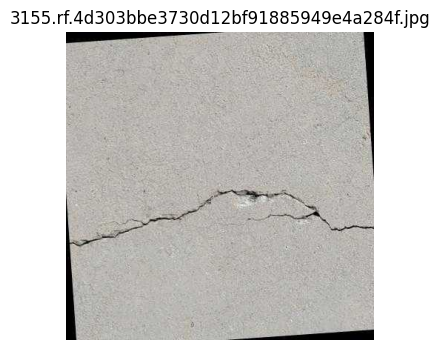

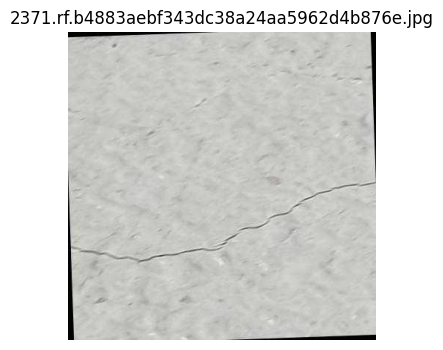

In [2]:
# 1. Install dependencies
!pip install -q ultralytics opencv-python matplotlib

import os
from glob import glob
import cv2
import matplotlib.pyplot as plt

# 2. Set dataset root exactly as seen
DATA_ROOT = "/kaggle/input/datasets/akashbhavanisankar/crack-seg-ultralytics"
print("DATA_ROOT:", DATA_ROOT)

# 3. Quick check of images
train_imgs = glob(f"{DATA_ROOT}/images/train/*")
val_imgs   = glob(f"{DATA_ROOT}/images/val/*")
test_imgs  = glob(f"{DATA_ROOT}/images/test/*")

print("Train images:", len(train_imgs))
print("Val images:",   len(val_imgs))
print("Test images:",  len(test_imgs))

# 4. Optional: visualize a few training images
for path in train_imgs[:3]:
    img = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(4,4))
    plt.imshow(img)
    plt.title(os.path.basename(path))
    plt.axis("off")
    plt.show()

In [3]:
def check_pairs(split):
    img_dir = f"{DATA_ROOT}/images/{split}"
    lbl_dir = f"{DATA_ROOT}/labels/{split}"

    imgs = sorted([f for f in os.listdir(img_dir) if f.lower().endswith((".jpg", ".png", ".jpeg"))])
    lbls = sorted([f for f in os.listdir(lbl_dir) if f.lower().endswith(".txt")])

    print(f"\nSplit: {split}")
    print("Images:", len(imgs), "Labels:", len(lbls))

    missing = []
    for img in imgs:
        base = os.path.splitext(img)[0]
        if f"{base}.txt" not in lbls:
            missing.append(img)

    print("Images without labels:", len(missing))
    if missing:
        print("First few without labels:", missing[:5])

for sp in ["train", "val", "test"]:
    check_pairs(sp)


Split: train
Images: 3717 Labels: 3717
Images without labels: 0

Split: val
Images: 200 Labels: 200
Images without labels: 0

Split: test
Images: 112 Labels: 112
Images without labels: 0


In [4]:
import textwrap
import os

yaml_text = f"""
path: {DATA_ROOT}
train: images/train
val: images/val
test: images/test

names:
  0: crack
"""

os.makedirs("/kaggle/working", exist_ok=True)
with open("/kaggle/working/crack-seg-detect.yaml", "w") as f:
    f.write(textwrap.dedent(yaml_text))

print(open("/kaggle/working/crack-seg-detect.yaml").read())


path: /kaggle/input/datasets/akashbhavanisankar/crack-seg-ultralytics
train: images/train
val: images/val
test: images/test

names:
  0: crack



In [5]:
from ultralytics import YOLO

# small model first; switch to yolov8n.pt or a larger model later if you want
model = YOLO("yolo11n.pt")

results = model.train(
    data="/kaggle/working/crack-seg-detect.yaml",
    epochs=50,          # you can increase to 100 if GPU allows
    imgsz=640,
    batch=16,
    patience=10,        # early stopping
    project="/kaggle/working/runs",
    name="crack_detect",
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.45 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/crack-seg-detect.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_

In [6]:
metrics = model.val(
    data="/kaggle/working/crack-seg-detect.yaml",
    imgsz=640
)
print(metrics)

Ultralytics 8.4.45 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 29.8±19.4 MB/s, size: 20.2 KB)
val: Scanning /kaggle/input/datasets/akashbhavanisankar/crack-seg-ultralytics/labels/val... 200 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 200/200 626.4it/s 0.3s0.0s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/akashbhavanisankar/crack-seg-ultralytics/labels is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 4.8it/s 2.7s0.1s
                   all        200        249      0.883      0.743      0.812      0.638
Speed: 1.9ms preprocess, 4.5ms inference, 0.0ms loss, 2.3ms postprocess per image
Results saved to /kaggle/working/runs/detect/val
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
b

In [7]:
pred = model.predict(
    source=f"{DATA_ROOT}/images/test",
    imgsz=640,
    conf=0.25,
    save=True,
    project="/kaggle/working/runs",
    name="crack_detect_infer",
)


image 1/112 /kaggle/input/datasets/akashbhavanisankar/crack-seg-ultralytics/images/test/1616.rf.c868709931a671796794fdbb95352c5a.jpg: 640x640 2 cracks, 8.1ms
image 2/112 /kaggle/input/datasets/akashbhavanisankar/crack-seg-ultralytics/images/test/1675.rf.e3aa3f8d28d0247ef0284dd46dacc29f.jpg: 640x640 1 crack, 7.9ms
image 3/112 /kaggle/input/datasets/akashbhavanisankar/crack-seg-ultralytics/images/test/1686.rf.809fb1b51c607e5cf787e44ef4ddd7b8.jpg: 640x640 2 cracks, 7.8ms
image 4/112 /kaggle/input/datasets/akashbhavanisankar/crack-seg-ultralytics/images/test/1706.rf.011d213c21ec78896c36728dcbc156f5.jpg: 640x640 1 crack, 7.8ms
image 5/112 /kaggle/input/datasets/akashbhavanisankar/crack-seg-ultralytics/images/test/1716.rf.85ea38b36008beaa72c5d8541f734eb0.jpg: 640x640 2 cracks, 7.8ms
image 6/112 /kaggle/input/datasets/akashbhavanisankar/crack-seg-ultralytics/images/test/1722.rf.38b38f2e833309a4f35bfbf0432dffff.jpg: 640x640 1 crack, 7.8ms
image 7/112 /kaggle/input/datasets/akashbhavanisankar/

In [10]:
import glob
import cv2
import matplotlib.pyplot as plt
import os

pred_dir = "/kaggle/working/runs/crack_detect_infer/predict"
pred_imgs = glob.glob(os.path.join(pred_dir, "*"))

for path in pred_imgs[:4]:
    img = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(5,5))
    plt.imshow(img)
    plt.title(os.path.basename(path))
    plt.axis("off")
    plt.show()

In [11]:
import shutil

best_src = "/kaggle/working/runs/crack_detect/weights/best.pt"
best_dst = "/kaggle/working/models/yolo_crack_detect_best.pt"

os.makedirs("/kaggle/working/models", exist_ok=True)

if os.path.exists(best_src):
    shutil.copy(best_src, best_dst)
    print("Saved best model:", best_dst)
else:
    print("best.pt not found; check /kaggle/working/runs/crack_detect/weights/")

Saved best model: /kaggle/working/models/yolo_crack_detect_best.pt


In [13]:
import os
print(os.path.exists("/kaggle/working/models/yolo_crack_detect_best.pt"))

True


In [14]:
from ultralytics import YOLO
import gradio as gr
import cv2

MODEL_PATH = "/kaggle/working/models/yolo_crack_detect_best.pt"  # full path in Kaggle
model = YOLO(MODEL_PATH)

def detect_cracks(image):
    results = model(image, imgsz=640, conf=0.25)
    annotated_bgr = results[0].plot()
    annotated_rgb = cv2.cvtColor(annotated_bgr, cv2.COLOR_BGR2RGB)
    return annotated_rgb

demo = gr.Interface(
    fn=detect_cracks,
    inputs=gr.Image(type="numpy", label="Upload wall/road/beam image"),
    outputs=gr.Image(type="numpy", label="Crack detection result")
)

demo.launch()

* Running on local URL:  http://127.0.0.1:7860
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

* Running on public URL: https://b3d0be9bea242decc3.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)



0: 640x640 2 cracks, 10.0ms
Speed: 2.6ms preprocess, 10.0ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)
Created dataset file at: .gradio/flagged/dataset1.csv
